In [327]:
import numpy as np 
import matplotlib.pyplot as plt
import os
from aeon.visualisation import plot_critical_difference
import pandas as pd

def load_npz(path):
    data = np.load(path)
    return {k: data[k] for k in data.files}

In [328]:
# 64, 128, 256, 512, 1024
CTX_LEN=256
ABL_K=True

In [329]:
dic_model_colors = {
    "Prefix RevIN":              "#FF3300",  # bright red-orange
    "Prefix RevIN + asinh":      "#CC0099",  # strong magenta
    "Prefix RevIN 2":            "#9900CC",  # deep purple
    "Prefix RevIN 2 + asinh":    "#33CCFF",  # bright cyan
    "Prefix RevIN k=4":          "#009933",  # strong green
    "Prefix RevIN k=2":          "#FFCC00",  # bright yellow
    
}

dic_model_symbols = {
    "Prefix RevIN":              "^",   # triangle up
    "Prefix RevIN + asinh":      "v",   # triangle down
    "Prefix RevIN 2":            "P",   # plus (filled)
    "Prefix RevIN 2 + asinh":    "*",   # star
    "Prefix RevIN k=4":          "D",   # diamond (filled)
    "Prefix RevIN k=2":          "o",   # circle (filled)
}

In [330]:
base_dir = "../processed_results" 

# =========================
# PrefixRevIN_False
# =========================
metrics_prefix_gift_eval = load_npz(os.path.join(
    base_dir, "PrefixRevIN_False", str(CTX_LEN), "results_gift_eval.npz"
))
metrics_prefix_utsd = load_npz(os.path.join(
    base_dir, "PrefixRevIN_False", str(CTX_LEN), "results_utsd.npz"
))
metrics_prefix_artificial = load_npz(os.path.join(
    base_dir, "PrefixRevIN_False", str(CTX_LEN), "results_artificial.npz"
))

# =========================
# PrefixRevIN_True
# =========================
metrics_prefix_asinh_gift_eval = load_npz(os.path.join(
    base_dir, "PrefixRevIN_True", str(CTX_LEN), "results_gift_eval.npz"
))
metrics_prefix_asinh_utsd = load_npz(os.path.join(
    base_dir, "PrefixRevIN_True", str(CTX_LEN), "results_utsd.npz"
))
metrics_prefix_asinh_artificial = load_npz(os.path.join(
    base_dir, "PrefixRevIN_True", str(CTX_LEN), "results_artificial.npz"
))

# =========================
# PrefixRevIN2_False
# =========================
metrics_prefix2_gift_eval = load_npz(os.path.join(
    base_dir, "PrefixRevIN2_False", str(CTX_LEN), "results_gift_eval.npz"
))
metrics_prefix2_utsd = load_npz(os.path.join(
    base_dir, "PrefixRevIN2_False", str(CTX_LEN), "results_utsd.npz"
))
metrics_prefix2_artificial = load_npz(os.path.join(
    base_dir, "PrefixRevIN2_False", str(CTX_LEN), "results_artificial.npz"
))

# =========================
# PrefixRevIN2_True
# =========================
metrics_prefix2_asinh_gift_eval = load_npz(os.path.join(
    base_dir, "PrefixRevIN2_True", str(CTX_LEN), "results_gift_eval.npz"
))
metrics_prefix2_asinh_utsd = load_npz(os.path.join(
    base_dir, "PrefixRevIN2_True", str(CTX_LEN), "results_utsd.npz"
))
metrics_prefix2_asinh_artificial = load_npz(os.path.join(
    base_dir, "PrefixRevIN2_True", str(CTX_LEN), "results_artificial.npz"
))

# =========================
# PrefixRevIN_False_abl_k4
# =========================
metrics_prefix_abl_k4_gift_eval = load_npz(os.path.join(
    base_dir, "PrefixRevIN_ablation_k4_False", str(CTX_LEN), "results_gift_eval.npz"
))
metrics_prefix_abl_k4_utsd = load_npz(os.path.join(
    base_dir, "PrefixRevIN_ablation_k4_False", str(CTX_LEN), "results_utsd.npz"
))
metrics_prefix_abl_k4_artificial = load_npz(os.path.join(
    base_dir, "PrefixRevIN_ablation_k4_False", str(CTX_LEN), "results_artificial.npz"
))

# =========================
# PrefixRevIN_False_abl_k2
# =========================
metrics_prefix_abl_k2_gift_eval = load_npz(os.path.join(
    base_dir, "PrefixRevIN_ablation_k2_False", str(CTX_LEN), "results_gift_eval.npz"
))
metrics_prefix_abl_k2_utsd = load_npz(os.path.join(
    base_dir, "PrefixRevIN_ablation_k2_False", str(CTX_LEN), "results_utsd.npz"
))
metrics_prefix_abl_k2_artificial = load_npz(os.path.join(
    base_dir, "PrefixRevIN_ablation_k2_False", str(CTX_LEN), "results_artificial.npz"
))

# GIFT-Eval

In [331]:
all_mae_prefix, all_rmse_prefix, all_mase_prefix, all_sql_prefix, sizes = [], [], [], [], []
for k, v in metrics_prefix_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix.append(np.mean(v))
        sizes.append(size)
    elif metric.lower() == "rmse":
        all_rmse_prefix.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix.append(np.mean(v))
        
all_mae_prefix_asinh, all_rmse_prefix_asinh, all_mase_prefix_asinh, all_sql_prefix_asinh = [], [], [], []
for k, v in metrics_prefix_asinh_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_asinh.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix_asinh.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix_asinh.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix_asinh.append(np.mean(v))

all_mae_prefix, all_rmse_prefix, all_mase_prefix, all_sql_prefix = [], [], [], []
for k, v in metrics_prefix_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix.append(np.mean(v))

all_mae_prefix2_asinh, all_rmse_prefix2_asinh, all_mase_prefix2_asinh, all_sql_prefix2_asinh = [], [], [], []
for k, v in metrics_prefix2_asinh_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2_asinh.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix2_asinh.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix2_asinh.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix2_asinh.append(np.mean(v))

all_mae_prefix2, all_rmse_prefix2, all_mase_prefix2, all_sql_prefix2 = [], [], [], []
for k, v in metrics_prefix2_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix2.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix2.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix2.append(np.mean(v))

all_mae_prefix_abl_k4, all_rmse_prefix_abl_k4, all_mase_prefix_abl_k4, all_sql_prefix_abl_k4 = [], [], [], []
for k, v in metrics_prefix_abl_k4_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_abl_k4.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix_abl_k4.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix_abl_k4.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix_abl_k4.append(np.mean(v))

all_mae_prefix_abl_k2, all_rmse_prefix_abl_k2, all_mase_prefix_abl_k2, all_sql_prefix_abl_k2 = [], [], [], []
for k, v in metrics_prefix_abl_k2_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_abl_k2.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix_abl_k2.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix_abl_k2.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix_abl_k2.append(np.mean(v))

In [332]:
FIGSIZE = (8, 5)
FONTSIZE = 14
FONTSIZE_TITLE = 17

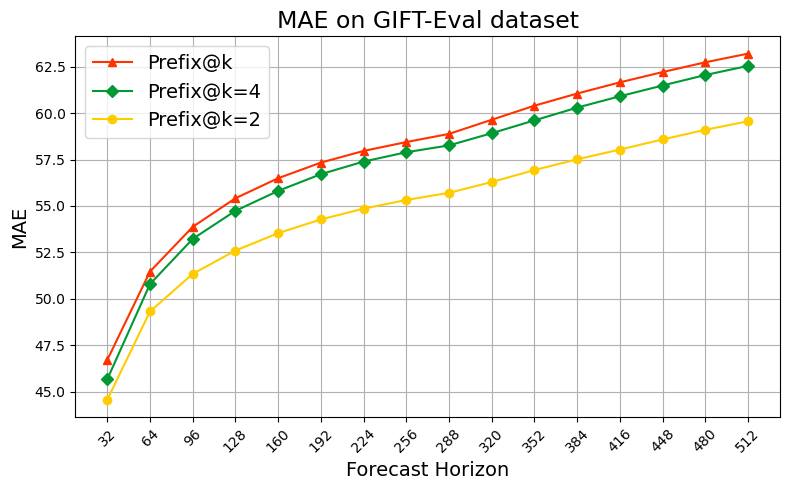

In [333]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mae_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_mae_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_mae_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_mae_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_mae_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_mae_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MAE on GIFT-Eval dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MAE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mae_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

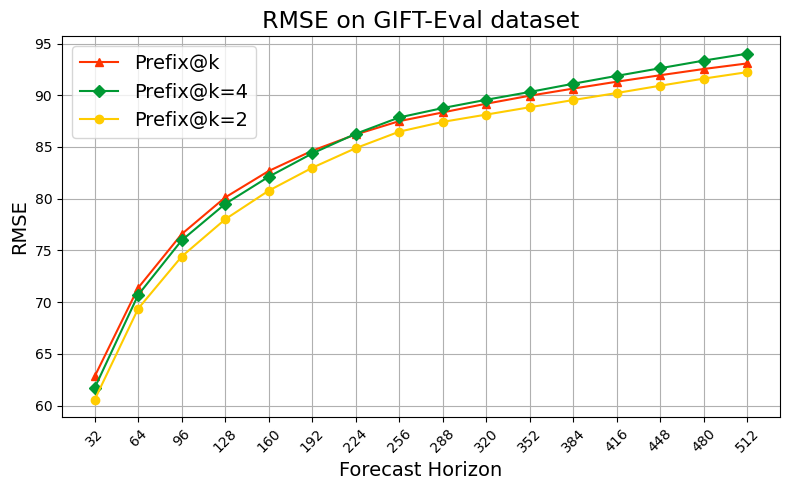

In [334]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_rmse_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_rmse_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_rmse_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_rmse_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_rmse_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_rmse_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("RMSE on GIFT-Eval dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("RMSE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/rmse_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

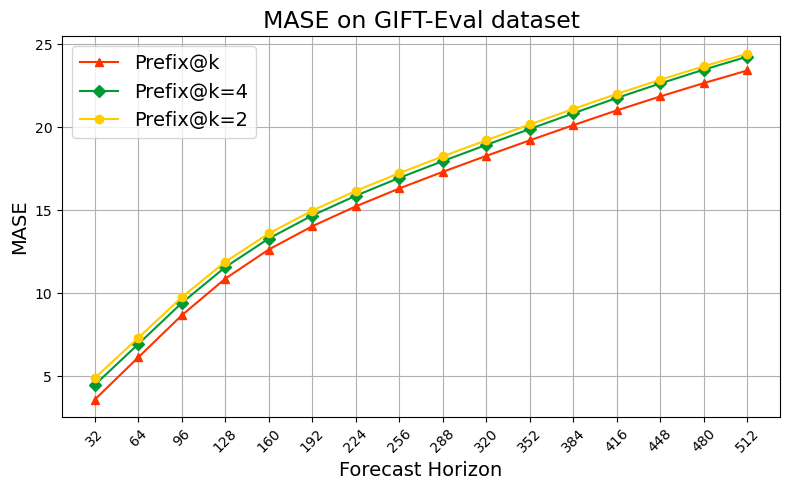

In [335]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mase_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_mase_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_mase_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_mase_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_mase_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_mase_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MASE on GIFT-Eval dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MASE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mase_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

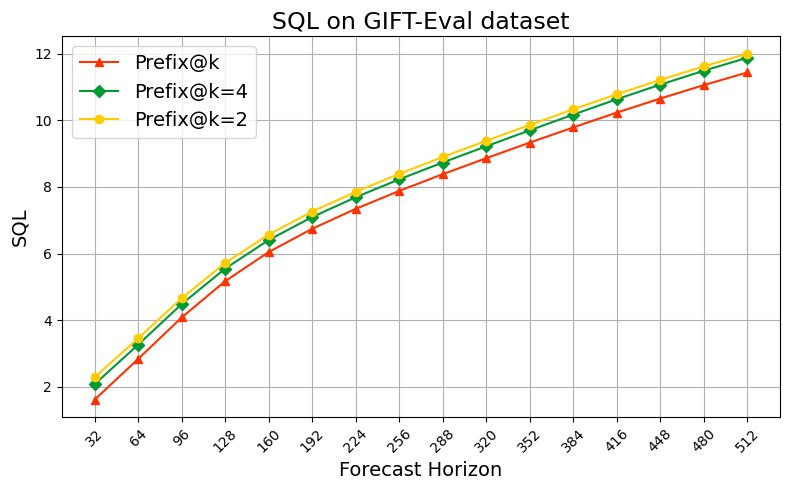

In [336]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_sql_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_sql_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_sql_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_sql_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_sql_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_sql_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("SQL on GIFT-Eval dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("SQL", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/sql_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

# UTSD

In [337]:
all_mae_prefix, all_rmse_prefix, all_mase_prefix, all_sql_prefix, sizes = [], [], [], [], []
for k, v in metrics_prefix_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix.append(np.mean(v))
        sizes.append(size)
    elif metric.lower() == "rmse":
        all_rmse_prefix.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix.append(np.mean(v))

all_mae_prefix_asinh, all_rmse_prefix_asinh, all_mase_prefix_asinh, all_sql_prefix_asinh = [], [], [], []
for k, v in metrics_prefix_asinh_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_asinh.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix_asinh.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix_asinh.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix_asinh.append(np.mean(v))

all_mae_prefix2, all_rmse_prefix2, all_mase_prefix2, all_sql_prefix2 = [], [], [], []
for k, v in metrics_prefix2_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix2.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix2.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix2.append(np.mean(v))

all_mae_prefix2_asinh, all_rmse_prefix2_asinh, all_mase_prefix2_asinh, all_sql_prefix2_asinh = [], [], [], []
for k, v in metrics_prefix2_asinh_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2_asinh.append(np.mean(v))    
    elif metric.lower() == "rmse":
        all_rmse_prefix2_asinh.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix2_asinh.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix2_asinh.append(np.mean(v))

all_mae_prefix_abl_k4, all_rmse_prefix_abl_k4, all_mase_prefix_abl_k4, all_sql_prefix_abl_k4 = [], [], [], []
for k, v in metrics_prefix_abl_k4_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_abl_k4.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix_abl_k4.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix_abl_k4.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix_abl_k4.append(np.mean(v))

all_mae_prefix_abl_k2, all_rmse_prefix_abl_k2, all_mase_prefix_abl_k2, all_sql_prefix_abl_k2 = [], [], [], []
for k, v in metrics_prefix_abl_k2_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_abl_k2.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix_abl_k2.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix_abl_k2.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix_abl_k2.append(np.mean(v))

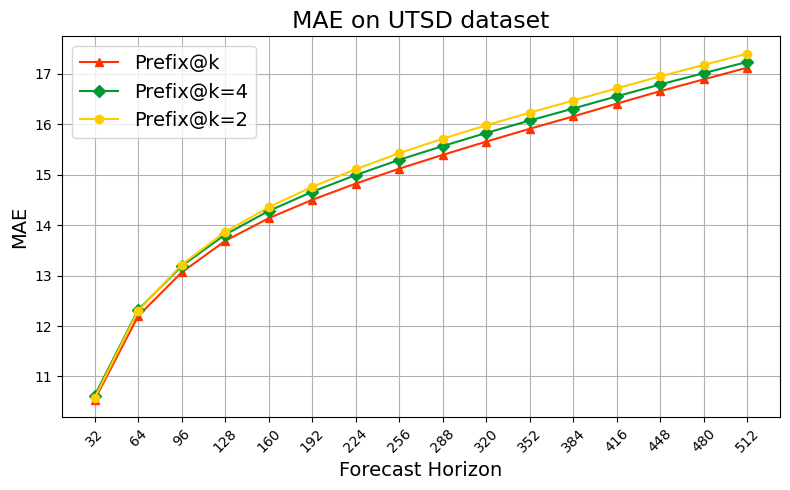

In [338]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mae_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_mae_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_mae_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_mae_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_mae_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_mae_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MAE on UTSD dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MAE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mae_ranking_horizon_utsd_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

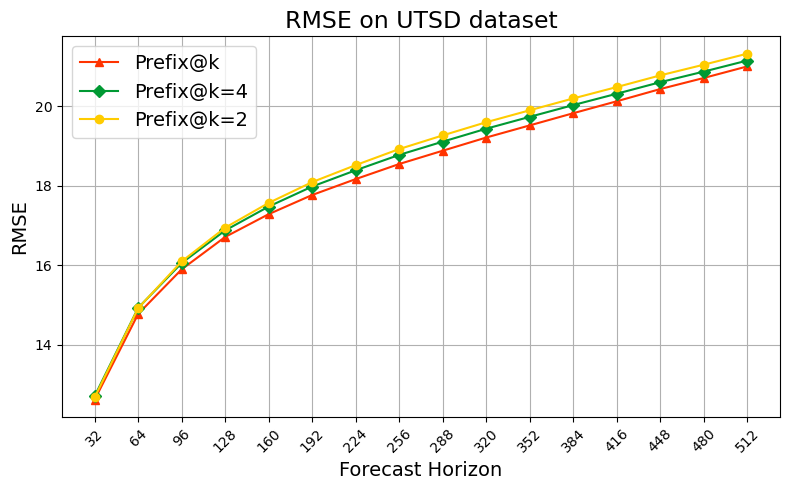

In [339]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_rmse_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_rmse_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_rmse_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_rmse_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_rmse_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_rmse_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("RMSE on UTSD dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("RMSE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/rmse_ranking_horizon_utsd_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

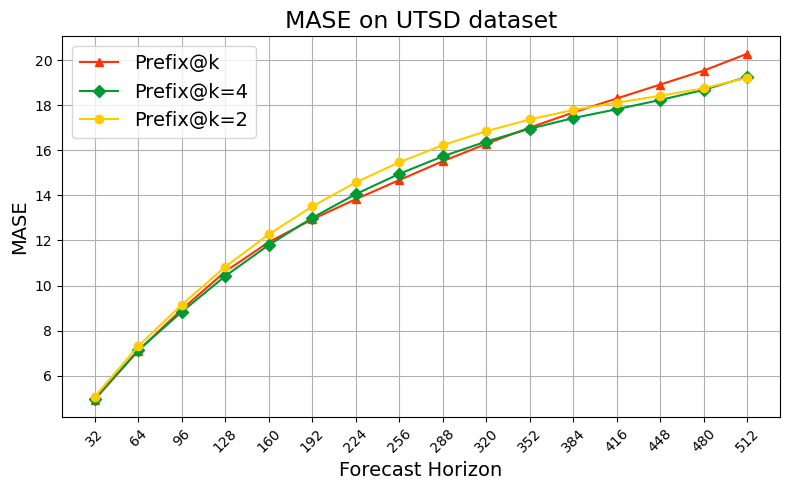

In [340]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mase_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_mase_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_mase_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_mase_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_mase_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_mase_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MASE on UTSD dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MASE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mase_ranking_horizon_utsd_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

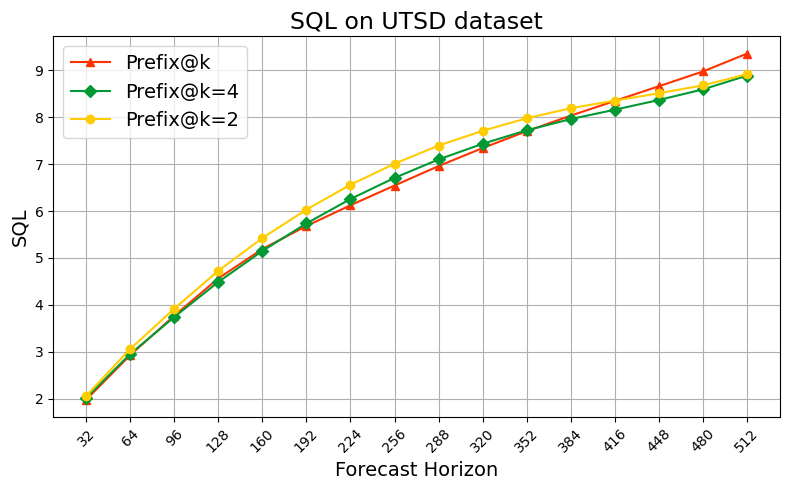

In [341]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_sql_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_sql_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_sql_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_sql_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_sql_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_sql_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("SQL on UTSD dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("SQL", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/sql_ranking_horizon_utsd_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

# Artificial

In [342]:
all_mae_prefix, all_rmse_prefix, all_mase_prefix, all_sql_prefix, sizes = [], [], [], [], []
for k, v in metrics_prefix_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix.append(np.mean(v))
        sizes.append(size)
    elif metric.lower() == "rmse":
        all_rmse_prefix.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix.append(np.mean(v))

all_mae_prefix_asinh, all_rmse_prefix_asinh, all_mase_prefix_asinh, all_sql_prefix_asinh = [], [], [], []
for k, v in metrics_prefix_asinh_artificial.items(): 
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_asinh.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix_asinh.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix_asinh.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix_asinh.append(np.mean(v))

all_mae_prefix2, all_rmse_prefix2, all_mase_prefix2, all_sql_prefix2 = [], [], [], []
for k, v in metrics_prefix2_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2.append(np.mean(v))  
    elif metric.lower() == "rmse":
        all_rmse_prefix2.append(np.mean(v))  
    elif metric.lower() == "mase":
        all_mase_prefix2.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix2.append(np.mean(v))

all_mae_prefix2_asinh, all_rmse_prefix2_asinh, all_mase_prefix2_asinh, all_sql_prefix2_asinh = [], [], [], []
for k, v in metrics_prefix2_asinh_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2_asinh.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix2_asinh.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix2_asinh.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix2_asinh.append(np.mean(v))

all_mae_prefix_abl_k4, all_rmse_prefix_abl_k4, all_mase_prefix_abl_k4, all_sql_prefix_abl_k4 = [], [], [], []
for k, v in metrics_prefix_abl_k4_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_abl_k4.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix_abl_k4.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix_abl_k4.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix_abl_k4.append(np.mean(v))

all_mae_prefix_abl_k2, all_rmse_prefix_abl_k2, all_mase_prefix_abl_k2, all_sql_prefix_abl_k2 = [], [], [], []
for k, v in metrics_prefix_abl_k2_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_abl_k2.append(np.mean(v))
    elif metric.lower() == "rmse":
        all_rmse_prefix_abl_k2.append(np.mean(v))
    elif metric.lower() == "mase":
        all_mase_prefix_abl_k2.append(np.mean(v))
    elif metric.lower() == "sql":
        all_sql_prefix_abl_k2.append(np.mean(v))

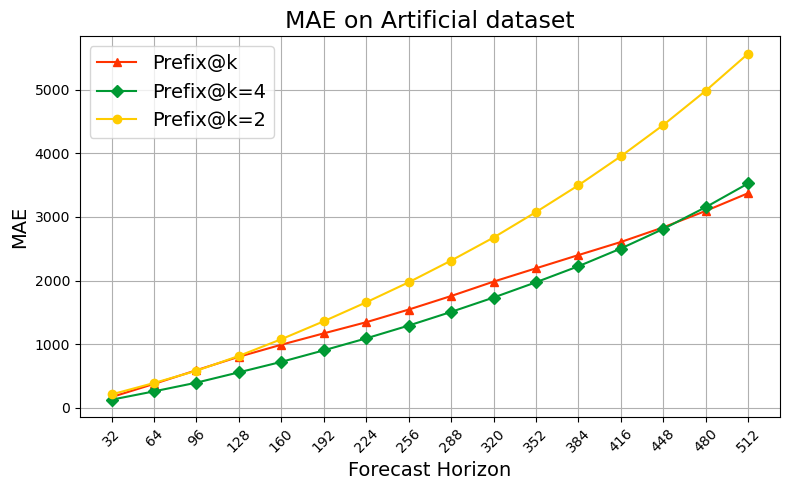

In [343]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mae_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_mae_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_mae_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_mae_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_mae_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_mae_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MAE on Artificial dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MAE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mae_ranking_horizon_artificial_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

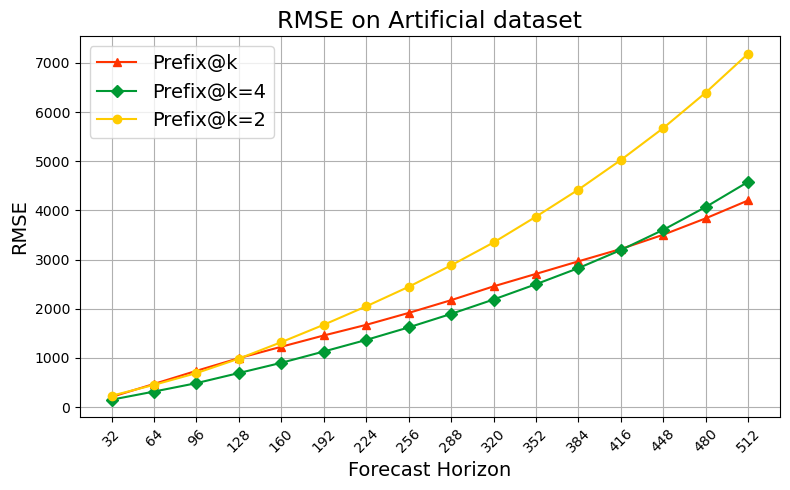

In [344]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_rmse_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_rmse_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_rmse_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_rmse_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_rmse_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_rmse_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("RMSE on Artificial dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("RMSE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/rmse_ranking_horizon_artificial_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

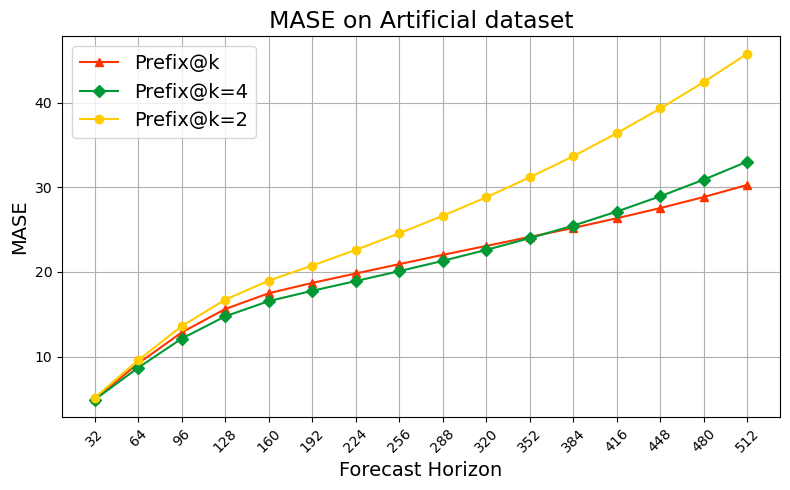

In [345]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mase_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_mase_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_mase_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_mase_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_mase_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_mase_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MASE on Artificial dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MASE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mase_ranking_horizon_artificial_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

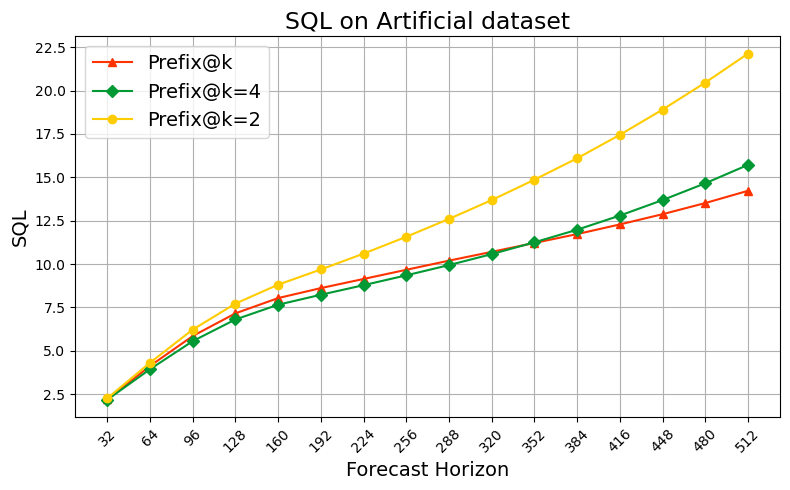

In [346]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_sql_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k", color=dic_model_colors["Prefix RevIN"])
if not ABL_K:
    plt.plot(all_sql_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label=r"Prefix@k + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN + asinh"])
    plt.plot(all_sql_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k V2", color=dic_model_colors["Prefix RevIN 2"])
    plt.plot(all_sql_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label=r"Prefix@k V2 + $\sinh^{-1}$", color=dic_model_colors["Prefix RevIN 2 + asinh"])
else:
    plt.plot(all_sql_prefix_abl_k4, marker=dic_model_symbols["Prefix RevIN k=4"], label="Prefix@k=4", color=dic_model_colors["Prefix RevIN k=4"])
    plt.plot(all_sql_prefix_abl_k2, marker=dic_model_symbols["Prefix RevIN k=2"], label="Prefix@k=2", color=dic_model_colors["Prefix RevIN k=2"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("SQL on Artificial dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("SQL", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/sql_ranking_horizon_artificial_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

# Critical Rank Diagram

In [347]:
full_df = {}
full_df['Prefix RevIN'] = {
    'GIFT-Eval': metrics_prefix_gift_eval,
    'UTSD': metrics_prefix_utsd,
    'Artificial': metrics_prefix_artificial
}
if not ABL_K:
    full_df['Prefix RevIN + asinh'] = {
        'GIFT-Eval': metrics_prefix_asinh_gift_eval,
        'UTSD': metrics_prefix_asinh_utsd,
        'Artificial': metrics_prefix_asinh_artificial
    }
    full_df['Prefix RevIN 2'] = {
        'GIFT-Eval': metrics_prefix2_gift_eval,
        'UTSD': metrics_prefix2_utsd,
        'Artificial': metrics_prefix2_artificial
    }
    full_df['Prefix RevIN 2 + asinh'] = {
        'GIFT-Eval': metrics_prefix2_asinh_gift_eval,
        'UTSD': metrics_prefix2_asinh_utsd,
        'Artificial': metrics_prefix2_asinh_artificial
    }
else:
    full_df['Prefix RevIN k=4'] = {
        'GIFT-Eval': metrics_prefix_abl_k4_gift_eval,
        'UTSD': metrics_prefix_abl_k4_utsd,
        'Artificial': metrics_prefix_abl_k4_artificial
    }
    full_df['Prefix RevIN k=2'] = {
        'GIFT-Eval': metrics_prefix_abl_k2_gift_eval,
        'UTSD': metrics_prefix_abl_k2_utsd,
        'Artificial': metrics_prefix_abl_k2_artificial
    }   

In [348]:
new_df_mae = {}
new_df_mse = {}
new_df_mase = {}
new_df_sql = {}
for model_name, datasets in full_df.items():
    new_df_mae[model_name] = {}
    new_df_mse[model_name] = {}
    new_df_mase[model_name] = {}
    new_df_sql[model_name] = {}
    for dataset_name, metrics in datasets.items():
        for k, v in metrics.items():
            metric, size = k.split("_")
            if metric.lower() == "mae":
                new_df_mae[model_name][f"{dataset_name}_{size}"] = np.mean(v)
            elif metric.lower() == "rmse":
                new_df_mse[model_name][f"{dataset_name}_{size}"] = np.mean(v) 
            elif metric.lower() == "mase":
                new_df_mase[model_name][f"{dataset_name}_{size}"] = np.mean(v)
            elif metric.lower() == "sql":
                new_df_sql[model_name][f"{dataset_name}_{size}"] = np.mean(v)

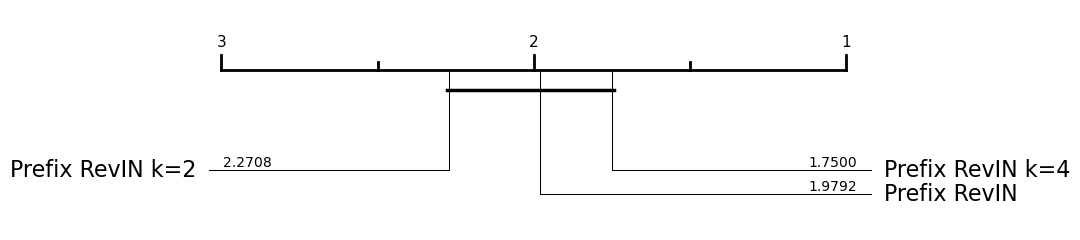

In [349]:
# Create Critical Difference plot for MAE
df_mae = pd.DataFrame(new_df_mae)
methods = df_mae.columns
plot = plot_critical_difference(df_mae.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

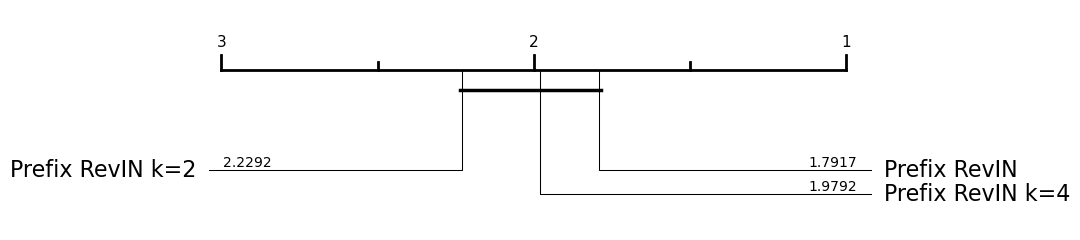

In [350]:
# Create Critical Difference plot for MSE
df_mse = pd.DataFrame(new_df_mse)
methods = df_mse.columns
plot = plot_critical_difference(df_mse.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

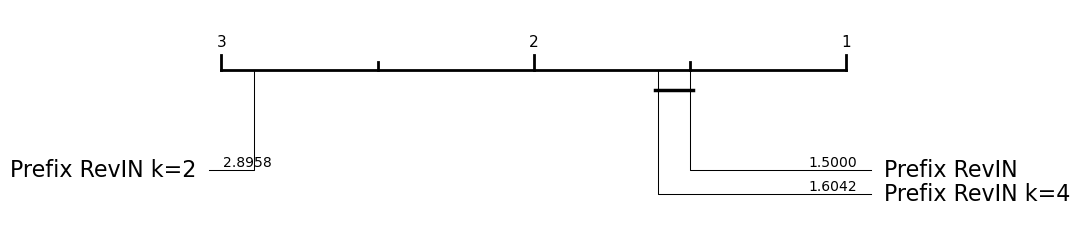

In [351]:
# Create Critical Difference plot for MASE
df_mase = pd.DataFrame(new_df_mase)
methods = df_mase.columns
plot = plot_critical_difference(df_mase.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

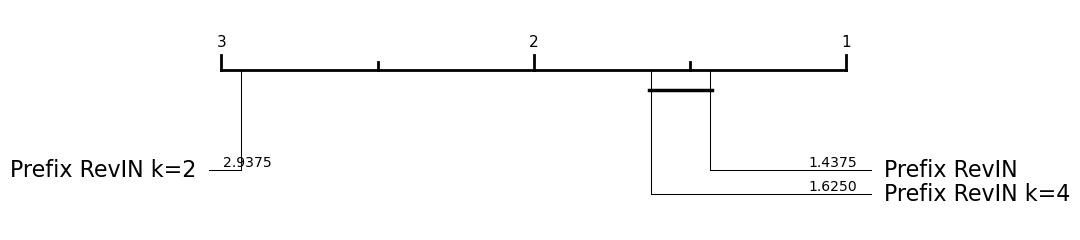

In [352]:
# Create Critical Difference plot for SQL
df_sql = pd.DataFrame(new_df_sql)
methods = df_sql.columns
plot = plot_critical_difference(df_sql.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)